# Presynaptic deployment: unlabeled analysis
Six-class CAVE n10 pre + post predictions, five folds, with each fold's own presynaptic axon filter. All eligible synapses contribute, including distinct synapses sharing the same presynaptic fragment. Missing-embedding rows and rows rejected by that fold's filter are excluded. Change `FAMILY` for single_pre_post.

This notebook reads compact cached histograms and sufficient statistics, not 160 million predictions into memory. Cache source: the completed deployment Parquet data and frozen model plan. Build caches with `sbatch analysis/db_deployment/presynaptic/20261009/build_cache.sh`.

“Selected probability” is the joint probability of the saved top-down class. There are no true labels here, so probability is not measured accuracy. The composite pools fold predictions, without averaging or deduplicating across folds.

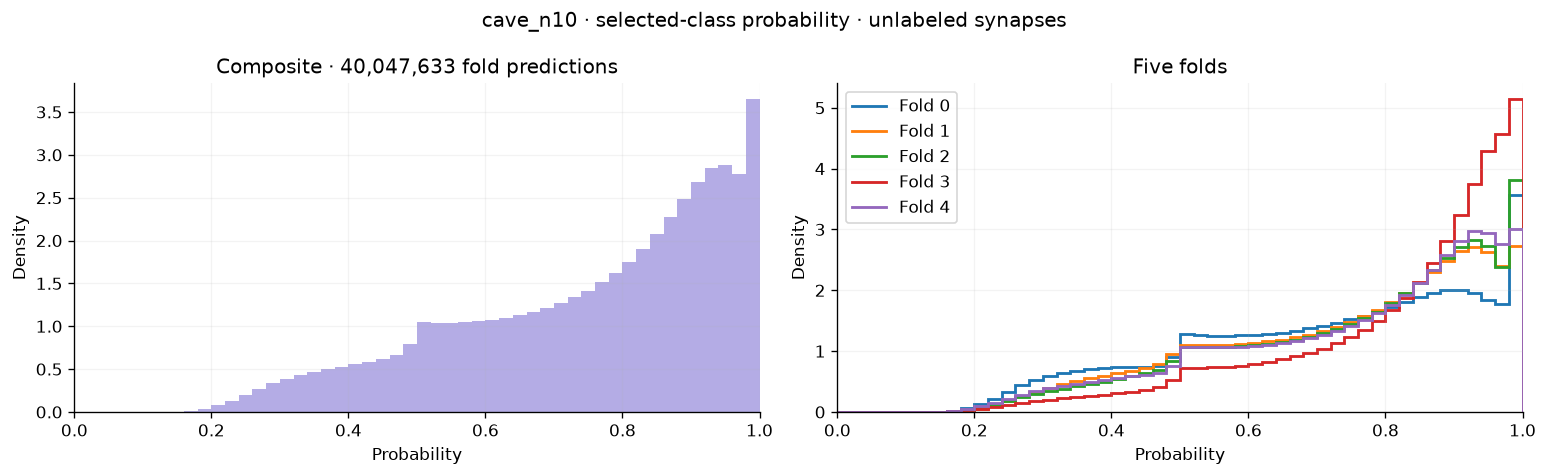

In [1]:
%matplotlib inline
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'scripts/train_gnn.py').is_file())
HERE = ROOT / 'analysis/db_deployment/presynaptic/20261009'
sys.path.insert(0, str(HERE))
from cache_analysis import CACHE, SOURCE, digest
from plot_helpers import histograms, probability_lines, probability_fold_mean, accuracy_plot, COLORS
FAMILY = 'cave_n10'  # Or 'single_pre_post'; build that family's cache first.
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
def load_folds(kind):
    paths = [CACHE / FAMILY / f'{kind}_fold{fold}.npz' for fold in range(5)]
    missing = [str(p) for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError('Build cached data with build_cache.sh first. Missing: ' + ', '.join(missing))
    result = []
    for fold, path in enumerate(paths):
        with np.load(path, allow_pickle=False) as z:
            result.append({k: z[k].copy() for k in z.files})
        provenance = json.loads(str(result[-1]['provenance']))
        if kind == 'unlabeled':
            assert provenance['format'] >= 2, 'Rebuild unlabeled caches for predicted-class filtering'
            assert provenance['plan_sha256'] == digest(SOURCE / 'plan.json'), 'Stale prediction plan'
        else:
            plan = json.loads((SOURCE / 'plan.json').read_text())
            model = next(m for m in plan['models'] if m['family'] == FAMILY and m['classes'] == 'six' and m['fold'] == fold)
            assert provenance['checkpoint_sha256'] == model['sha256'], 'Stale checkpoint'
            assert provenance['manifest_sha256'] == model['manifest_sha256'], 'Stale split manifest'
    assert all(np.array_equal(z['classes'], result[0]['classes']) for z in result)
    return result

folds = load_folds('unlabeled')
classes = folds[0]['classes'].tolist()
histograms([z['hist'] for z in folds], f'{FAMILY} · selected-class probability · unlabeled synapses', counts=True)

## Selected-class probability versus embeddings used
Each line is a fold's mean selected-class probability at the **actual number of embeddings used by that model**. Bands show nested 50%, 80%, and 95% normal confidence intervals for the mean (darker toward the center); the legend uses the same opacity gradient. These are descriptive point-level intervals, not root-cluster-adjusted uncertainty, and may be very narrow with millions of correlated synapses. CAVE uses up to 10; single_pre_post uses 1.

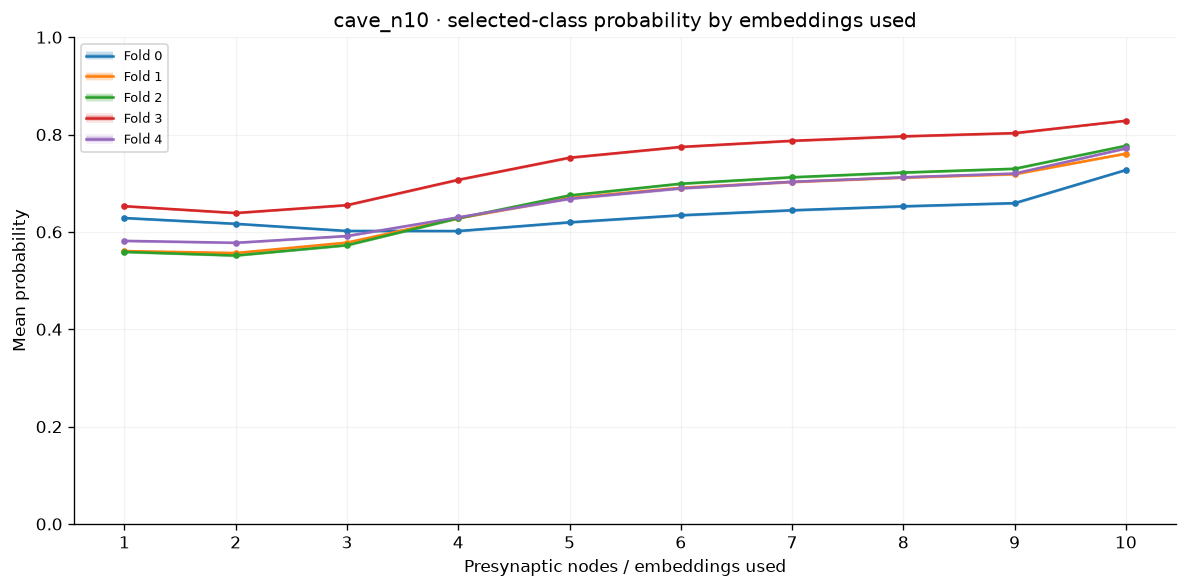

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
probability_lines(ax, folds, 0)
ax.set_title(f'{FAMILY} · selected-class probability by embeddings used')
fig.tight_layout(); plt.show()

## Selected-class probability by predicted cell type versus embeddings used
Each panel includes **only synapses predicted as that panel’s cell type**, using each fold’s saved top-down decision. First compute the mean selected-class joint probability within each fold and embedding count, then average those means with **equal fold weights**.

One line shows the mean across folds. The opacity gradient shows nested 50%, 80%, and 95% Student-t confidence intervals based on variability among fold means (normally five folds; 4 degrees of freedom). These describe variation across the fitted folds; overlapping prediction datasets mean they are not independent population uncertainty estimates. If a class/node count is absent in a fold, that fold is omitted at that point; intervals require at least two folds.

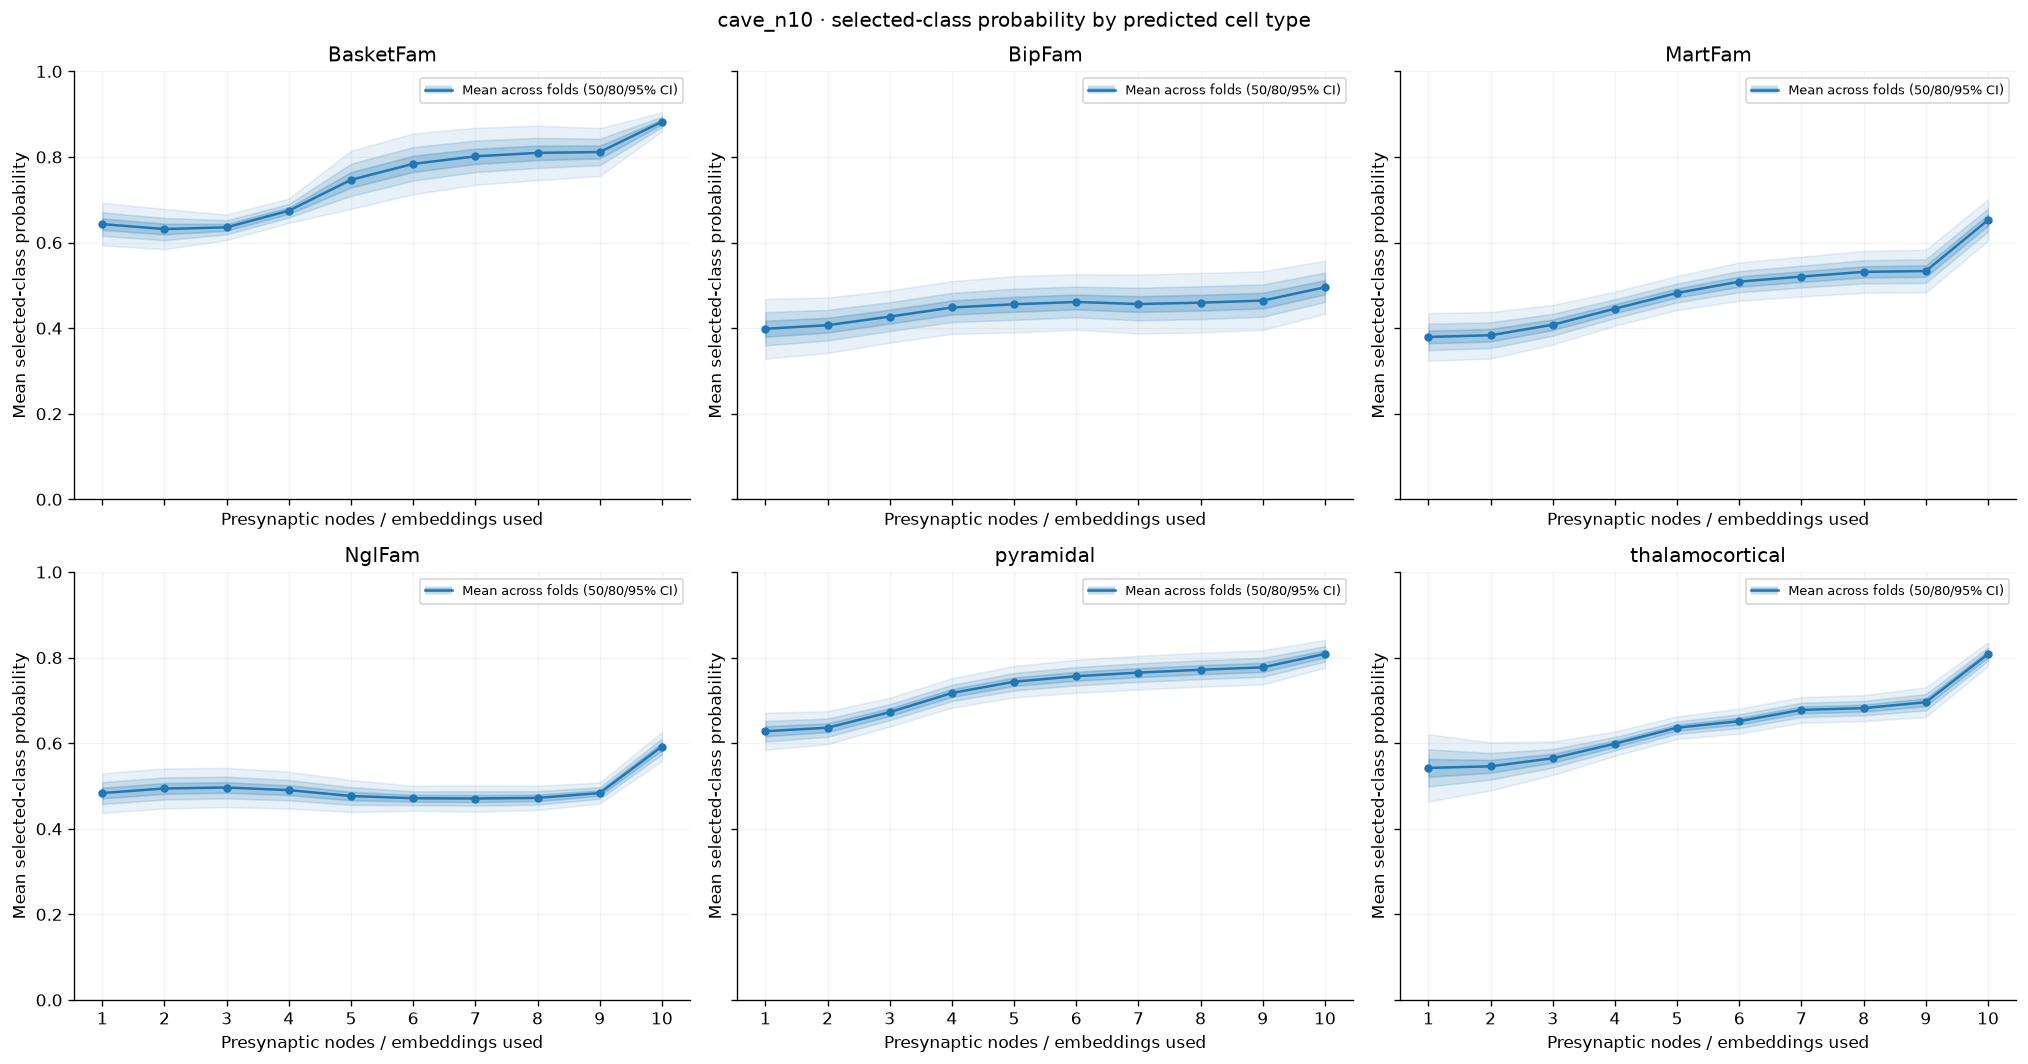

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True, sharey=True)
for j, (ax, label) in enumerate(zip(axes.flat, classes)):
    probability_fold_mean(ax, folds, j + 1)
    ax.set_title(label)
fig.suptitle(f'{FAMILY} · selected-class probability by predicted cell type')
fig.tight_layout(); plt.show()

## Support by fold and node count

In [4]:
display(pd.DataFrame({f'Fold {f}': z['n'] for f, z in enumerate(folds)}, index=pd.Index(range(1,11), name='Embeddings used')))

,Fold 0,Fold 1,Fold 2,Fold 3,Fold 4
Embeddings used,,,,,
1,128656,128223,129695,125602,130171
2,242367,243090,245119,239849,244923
3,234513,235578,236684,233868,236438
4,151560,151957,152194,151586,152104
5,121944,122076,122101,122032,122107
6,114145,114191,114188,114197,114212
7,110129,110181,110170,110176,110181
8,106202,106224,106229,106226,106231
9,102878,102892,102886,102886,102888


## Support per predicted class and embedding count
Counts used for each class-specific mean and confidence interval, separately for each fold.

In [5]:
for j, label in enumerate(classes):
    print(label)
    display(pd.DataFrame({f'Fold {f}': z['selected_class_n'][:, j] for f, z in enumerate(folds)}, index=pd.Index(range(1,11), name='Embeddings used')))

BasketFam


,Fold 0,Fold 1,Fold 2,Fold 3,Fold 4
Embeddings used,,,,,
1,69437,23983,32044,35364,41991
2,125876,42536,57040,68899,79989
3,94773,31398,40859,53157,62328
4,36527,12439,14777,19236,24212
5,18297,7494,8238,9621,12462
6,13437,6340,6865,7624,9499
7,11126,5667,6146,6676,8038
8,9539,5134,5592,5972,7064
9,8115,4521,4961,5270,6142


BipFam


,Fold 0,Fold 1,Fold 2,Fold 3,Fold 4
Embeddings used,,,,,
1,1858,2286,2279,5343,1707
2,5293,5454,6309,13766,4428
3,9427,6601,8714,17308,6044
4,9784,4880,7010,12528,5269
5,9222,3741,5298,9112,4178
6,8873,3441,4747,7580,3657
7,8699,3088,4191,6660,3315
8,8264,2836,3803,5836,3112
9,7956,2825,3582,5504,2948


MartFam


...

,Fold 0,Fold 1,Fold 2,Fold 3,Fold 4
Embeddings used,,,,,
1,6593,11846,10915,3132,10086
2,19624,31535,29663,9837,29110
3,23129,30552,29371,10832,30725
4,12213,11686,11648,4973,13409
5,6517,4524,4671,2244,5799
6,4341,2602,2773,1345,3538
7,3353,1842,2042,1003,2396
8,2619,1273,1489,772,1755
9,2195,984,1183,575,1322


pyramidal


,Fold 0,Fold 1,Fold 2,Fold 3,Fold 4
Embeddings used,,,,,
1,37967,56865,45124,53213,51118
2,61846,99068,86252,103803,86718
3,69131,103291,100403,119591,90562
4,63257,83656,86934,100395,76045
5,62415,76962,81069,92558,72136
6,63706,76088,80030,90868,72284
7,64426,75656,79381,89730,72511
8,64116,74570,78025,88176,71522
9,64058,73705,76955,86419,71268


thalamocortical


,Fold 0,Fold 1,Fold 2,Fold 3,Fold 4
Embeddings used,,,,,
1,888,12729,28528,27555,13165
2,2018,19995,39975,40838,16248
3,2832,16588,26666,28977,10954
4,2264,9037,10409,11269,4877
5,1694,5479,4986,5518,2784
6,1359,4154,3349,3753,2056
7,1282,3533,2774,3133,1833
8,1083,2934,2202,2541,1523
9,1086,2681,2077,2299,1446
